Nombre:

CI:

# Clase 6 — Evaluación y Selección de Modelos
**Profesor:** Prof. Dr. Pástor E Pérez Estigarribia (adaptado)  
**Objetivo del notebook:** consolidar conceptos de evaluación (matrices, ROC/AUC), validación cruzada y búsqueda de hiperparámetros (Grid / Randomized), y practicar con demos y desafíos reproducibles en Colab.  
**Archivos generados:** figuras en `figures/`, resúmenes en `outputs/`.  


## Objetivos de aprendizaje
Al finalizar este notebook el estudiante podrá:
- Explicar y calcular métricas de clasificación: accuracy, precision, recall, F1 y AUC.
- Interpretar una matriz de confusión y una curva ROC.
- Aplicar validación cruzada (k‑fold, stratified) y entender su utilidad.
- Ejecutar GridSearchCV y RandomizedSearchCV; comparar cobertura, coste y resultados.
- Implementar y evaluar un StackingClassifier y un árbol ponderado para datos desbalanceados.
- Diseñar una estrategia práctica de búsqueda de hiperparámetros (incluyendo estrategia híbrida).


## **3 — Imports y configuración**

In [ ]:
# Imports y configuración inicial
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', context='notebook')

from sklearn import datasets
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_val_score, GridSearchCV, RandomizedSearchCV,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Crear carpetas de salida
os.makedirs('figures', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# Semilla reproducible
RND = 42
np.random.seed(RND)


# **BLOQUE A — Implementaciones demostrativas**

### Demo A — ROC con validación cruzada
Objetivo: visualizar la curva ROC media y su variabilidad usando k‑fold CV; calcular AUC por fold y guardar figura `figures/roc_crossval.png`.


## **A.1 — Demo A: código**

In [ ]:
# Demo A: ROC con validación cruzada (Colab)
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn import svm

# Dataset binario más difícil de clasificar (versicolor vs virginica)
iris = datasets.load_iris()
# Seleccionar solo las clases versicolor (1) y virginica (2)
X = iris.data[iris.target != 0]
y = iris.target[iris.target != 0]
# Re-mapear las etiquetas a 0 y 1 para la clasificación binaria
y[y == 1] = 0 # versicolor se convierte en 0
y[y == 2] = 1 # virginica se convierte en 1

# Añadir ruido opcional para mayor dificultad (opcional)
rng = np.random.RandomState(RND)
X = np.c_[X, rng.randn(X.shape[0], 50)]

cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=RND)
classifier = SVC(kernel='linear', probability=True, random_state=RND)

tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 100)

for i, (train, test) in enumerate(cv.split(X, y), 1):
    probas_ = classifier.fit(X[train], y[train]).predict_proba(X[test])
    fpr, tpr, _ = roc_curve(y[test], probas_[:, 1])
    auc_score = auc(fpr, tpr)
    aucs.append(auc_score)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0

mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

plt.figure(figsize=(7,6))
for i, tpr in enumerate(tprs, 1):
    plt.plot(mean_fpr, tpr, color='gray', alpha=0.3, lw=1, label=f'ROC fold {i} (AUC={aucs[i-1]:.2f})')
plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC={mean_auc:.2f} ± {std_auc:.2f})')
plt.fill_between(mean_fpr, np.maximum(mean_tpr-std_tpr,0), np.minimum(mean_tpr+std_tpr,1), color='b', alpha=0.2)
plt.plot([0,1], [0,1], linestyle='--', color='k', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC con validación cruzada')
plt.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.savefig('figures/roc_crossval.png', dpi=150)
plt.show()

# Guardar resumen
with open('outputs/roc_crossval_summary.json', 'w') as f:
    json.dump({'aucs': [float(a) for a in aucs], 'mean_auc': float(mean_auc), 'std_auc': float(std_auc)}, f)
print('AUCs por fold:', np.round(aucs,3))
print('AUC medio ± std:', round(mean_auc,3), '±', round(std_auc,3))

**Preguntas (Demo A)**  
1. ¿Por qué interpolamos TPR sobre una malla común de FPR antes de promediar?  
2. Si la banda de desviación es amplia en FPR baja, ¿qué implicación práctica tiene para un sistema que requiere muy pocos falsos positivos?  
3. ¿Qué diferencia hay entre AUC medio (CV) y AUC calculado sobre un test final tras tuning? ¿Por qué usar nested CV si hacemos selección de hiperparámetros?


## **A.2 — Demo B: Stacking ensemble comparativo**

### Demo B — Stacking ensemble comparativo
Objetivo: comparar rendimiento de modelos base y del StackingClassifier usando cross_val_score; guardar `figures/stacking_comparison.png`.


## **A.2 — Demo B: código**

In [ ]:
# Demo B: Stacking ensemble comparativo
from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.ensemble import StackingClassifier

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=RND)

models = {
    'lr': LogisticRegression(max_iter=1000, random_state=RND),
    'knn': KNeighborsClassifier(),
    'cart': DecisionTreeClassifier(random_state=RND),
    'svm': SVC(probability=True, random_state=RND),
    'bayes': GaussianNB()
}

level0 = [('lr', LogisticRegression(max_iter=1000)),
          ('knn', KNeighborsClassifier()),
          ('cart', DecisionTreeClassifier(random_state=RND)),
          ('svm', SVC(probability=True, random_state=RND)),
          ('bayes', GaussianNB())]
meta = LogisticRegression(max_iter=1000)
stacking = StackingClassifier(estimators=level0, final_estimator=meta, cv=5, n_jobs=-1)
models['stacking'] = stacking

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RND)
results, names = [], []
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print(f'>{name} {np.mean(scores):.3f} ({np.std(scores):.3f})')

plt.figure(figsize=(9,5))
plt.boxplot(results, labels=names, showmeans=True)
plt.ylabel('Accuracy')
plt.title('Comparación modelos base vs stacking')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/stacking_comparison.png', dpi=150)
plt.show()


**Preguntas (Demo B)**  
1. ¿Qué papel juega el `final_estimator` en StackingClassifier y por qué suele elegirse un modelo simple como regresión logística?  
2. ¿Por qué es importante usar `cv` dentro de StackingClassifier al generar las predicciones para el metamodelo?  
3. Si el stacking no mejora respecto al mejor modelo base, ¿qué posibles causas investigarías?


## **Demo C — GridSearch vs RandomizedSearch (comparativa)**
Objetivo: comparar cobertura del espacio, tiempo y calidad de la mejor configuración entre GridSearchCV y RandomizedSearchCV usando SVC sobre Digits. Guardar heatmap y boxplot en `figures/`.

### **A.3 — Demo C: código**


In [ ]:
# Demo C: Grid vs Randomized Search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform

digits = datasets.load_digits()
X, y = digits.data, digits.target

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(probability=True, random_state=RND))])

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [1e-3, 1e-2, 1e-1, 1],
    'svc__kernel': ['rbf']
}
param_dist = {
    'svc__C': loguniform(1e-2, 1e3),
    'svc__gamma': loguniform(1e-4, 1e0),
    'svc__kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

# GridSearch
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', return_train_score=True, n_jobs=-1)
t0 = time.time()
grid.fit(X, y)
t_grid = time.time() - t0

# RandomizedSearch with same budget
n_iter = len(param_grid['svc__C']) * len(param_grid['svc__gamma'])
rand = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=n_iter, cv=cv, scoring='accuracy', random_state=RND, n_jobs=-1)
t1 = time.time()
rand.fit(X, y)
t_rand = time.time() - t1

summary = {
    'grid_best_params': grid.best_params_,
    'grid_best_score': float(grid.best_score_),
    'grid_time_s': float(t_grid),
    'rand_best_params': rand.best_params_,
    'rand_best_score': float(rand.best_score_),
    'rand_time_s': float(t_rand),
    'n_grid_evals': n_iter,
    'n_rand_evals': n_iter
}
with open('outputs/grid_vs_rand_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Grid best score:", grid.best_score_, "time (s):", round(t_grid,2))
print("Random best score:", rand.best_score_, "time (s):", round(t_rand,2))

# Heatmap del grid
grid_results = pd.DataFrame(grid.cv_results_)
grid_results['param_svc__gamma_str'] = grid_results['param_svc__gamma'].astype(str)
pivot = grid_results.pivot_table(values='mean_test_score', index='param_svc__C', columns='param_svc__gamma_str')

plt.figure(figsize=(7,5))
plt.title('GridSearch mean_test_score heatmap')
plt.imshow(pivot.values.astype(float), cmap='viridis', aspect='auto')
plt.colorbar(label='mean_test_score')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.savefig('figures/grid_heatmap.png', dpi=150)
plt.show()

# Boxplot comparativo
rand_results = pd.DataFrame(rand.cv_results_)
plt.figure(figsize=(6,5))
plt.boxplot([grid_results['mean_test_score'], rand_results['mean_test_score']], labels=['Grid', 'Randomized'], showmeans=True)
plt.ylabel('mean_test_score (cv)')
plt.title('Comparación distribución de mean_test_score')
plt.tight_layout()
plt.savefig('figures/grid_vs_rand_boxplot.png', dpi=150)
plt.show()

# Guardar resultados completos
grid_results.to_csv('outputs/grid_cv_results.csv', index=False)
rand_results.to_csv('outputs/rand_cv_results.csv', index=False)


**Preguntas (Demo C)**  
1. ¿Qué ventaja principal tiene GridSearchCV frente a RandomizedSearchCV?  
2. ¿En qué situaciones RandomizedSearchCV suele encontrar mejores configuraciones con menor coste?  
3. ¿Cómo afecta la elección de la distribución (por ejemplo loguniform) en RandomizedSearchCV al resultado?  
4. ¿Qué indica una celda del heatmap con score alto en GridSearch?  
5. ¿Por qué fijamos `n_iter` de RandomizedSearch igual al número de combinaciones del grid en esta demo?


# **GridSearchCV para MLPClassifier**

In [1]:
# GridSearch para MLPClassifier (Colab)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn import datasets
import json, time, os
os.makedirs('outputs', exist_ok=True)

RND = 42
X, y = datasets.load_digits(return_X_y=True)
pipe = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(random_state=RND, max_iter=300))])

param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50)],
    'mlp__alpha': [1e-4, 1e-3, 1e-2],
    'mlp__learning_rate_init': [1e-3, 1e-2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
t0 = time.time()
grid.fit(X, y)
t_grid = time.time() - t0

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
with open('outputs/mlp_grid_summary.json','w') as f:
    json.dump({'best_params': grid.best_params_, 'best_score': float(grid.best_score_), 'time_s': t_grid}, f)


Best params: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (100,), 'mlp__learning_rate_init': 0.001}
Best CV score: 0.9821928195605075


In [7]:
## RND es simplemente una variable que contiene la semilla (seed) para los generadores de números aleatorios
import numpy as np
RND = 42
np.random.seed(RND)
print(np.random.rand(3))  # siempre dará la misma secuencia si RND no cambia

# 42 es una elección arbitraria y muy habitual en ejemplos y tutoriales (referencia cultural a The Hitchhiker’s Guide to the Galaxy).


[0.37454012 0.95071431 0.73199394]


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **RandomizedSearchCV para MLPClassifier**

In [2]:
# RandomizedSearch para MLPClassifier (Colab)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform
import json, time

param_dist = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100,50), (200,)],
    'mlp__alpha': loguniform(1e-5, 1e-1),
    'mlp__learning_rate_init': loguniform(1e-4, 1e-1)
}

rand = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=20, cv=cv, scoring='accuracy', random_state=RND, n_jobs=-1)
t0 = time.time()
rand.fit(X, y)
t_rand = time.time() - t0

print("Random best params:", rand.best_params_)
print("Random best CV score:", rand.best_score_)
with open('outputs/mlp_rand_summary.json','w') as f:
    json.dump({'best_params': rand.best_params_, 'best_score': float(rand.best_score_), 'time_s': t_rand}, f)


Random best params: {'mlp__alpha': np.float64(6.788387912421223e-05), 'mlp__hidden_layer_sizes': (200,), 'mlp__learning_rate_init': np.float64(0.00035856126103454)}
Random best CV score: 0.9849721448467967


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **Nested CV para estimación robusta con MLP**

In [3]:
# Nested CV: outer CV para estimación, inner CV para selección (Colab)
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# usar param_grid reducido por tiempo
inner_grid = GridSearchCV(pipe, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

scores = cross_val_score(inner_grid, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
print("Nested CV scores:", np.round(scores,3))
print("Nested CV mean ± std:", np.round(scores.mean(),3), "±", np.round(scores.std(),3))


Nested CV scores: [0.981 0.981 0.983 0.981 0.972]
Nested CV mean ± std: 0.979 ± 0.004


**Actividad**

Utiliza la función explicar código y el asistente de notebookLM para relatar con tus propia palabras el flujo de trabajo implementado en la celda anterior:

# **ROC con CV para MLP (guardar figura)**

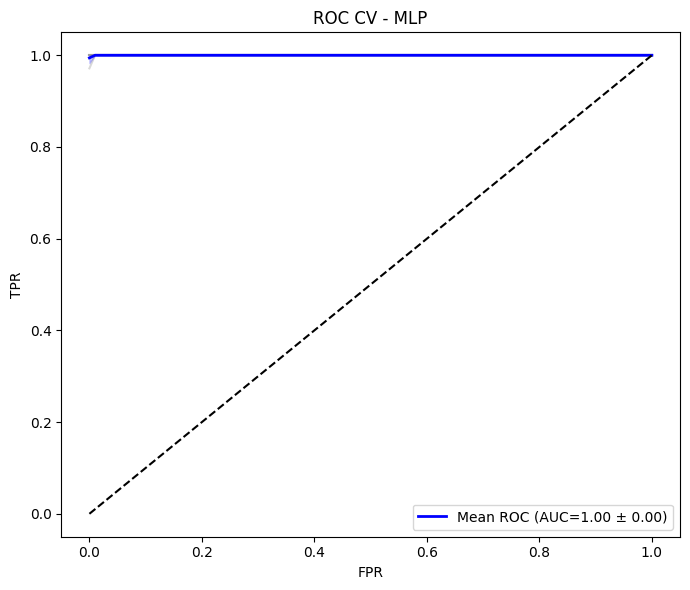

In [5]:
# ROC con CV para MLP (guardar figura)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# binarizar para clase vs resto (ejemplo con dígitos: clase 0 vs resto)
y_bin = (y == 0).astype(int)
clf = Pipeline([('scaler', StandardScaler()), ('mlp', MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=RND))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

tprs, aucs = [], []
mean_fpr = np.linspace(0,1,100)
for train, test in cv.split(X, y_bin):
    prob = clf.fit(X[train], y_bin[train]).predict_proba(X[test])[:,1]
    fpr, tpr, _ = roc_curve(y_bin[test], prob)
    aucs.append(auc(fpr,tpr))
    tprs.append(np.interp(mean_fpr, fpr, tpr))
mean_tpr = np.mean(tprs, axis=0)
plt.figure(figsize=(7,6))
for i, tpr in enumerate(tprs):
    plt.plot(mean_fpr, tpr, color='gray', alpha=0.3)
plt.plot(mean_fpr, mean_tpr, color='b', lw=2, label=f'Mean ROC (AUC={np.mean(aucs):.2f} ± {np.std(aucs):.2f})')
plt.fill_between(mean_fpr, np.maximum(mean_tpr-np.std(tprs,axis=0),0), np.minimum(mean_tpr+np.std(tprs,axis=0),1), color='b', alpha=0.2)
plt.plot([0,1],[0,1],'--',color='k')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC CV - MLP'); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('mlp_roc_cv.png', dpi=150); plt.show()


# **BLOQUE B — Actividades de desafío (para entregar)**

## Actividades de evaluación (entregables)
Realiza las tareas siguientes en el mismo notebook. Guarda figuras en `figures/` y tablas/resultados en `outputs/`. Entrega el notebook ejecutado (.ipynb) y un informe breve (Markdown) con respuestas y conclusiones.


**Desafío 1 — ROC comparativa**  
- Reproducir Demo A para tres clasificadores: LogisticRegression, RandomForestClassifier, SVC (RBF).  
- Entregables: `figures/roc_crossval_lr.png`, `figures/roc_crossval_rf.png`, `figures/roc_crossval_svc.png` y `outputs/roc_summary.csv` (AUC por fold y estadísticas).  
- Informe (5–8 líneas): cuál modelo tiene mejor AUC medio y cuál es más estable.


**Desafío 2 — Stacking + Pipelines + GridSearch**  
- Construir pipelines (StandardScaler + modelo) para cada base.  
- Crear StackingClassifier con pipelines como estimators.  
- Ejecutar GridSearchCV para ajustar `final_estimator__C` (LogisticRegression) y comparar con stacking sin preprocesado.  
- Entregables: `figures/stacking_grid.png`, `outputs/stacking_grid_results.csv`.  
- Informe: justificar preprocesado y comentar mejora (o ausencia de ella).


**Desafío 3 — Árbol ponderado (clases desbalanceadas)**  
- Generar dataset sintético con `make_classification` con proporción 1:100.  
- Ejecutar GridSearchCV sobre `class_weight` (valores propuestos en material).  
- Evaluar con RepeatedStratifiedKFold y ROC AUC.  
- Entregables: `outputs/grid_class_weight_results.csv` y breve informe (máx 1 página) con la mejor configuración y su interpretación.


**Desafío 4 — Nested CV**  
- Elegir un problema (Digits o dataset propio).  
- Realizar selección de modelo e hiperparámetros con GridSearchCV dentro de un outer CV (nested CV) para estimar rendimiento final.  
- Entregables: `outputs/nested_cv_summary.csv` con métricas por fold (media y std).  
- Informe: explicar por qué nested CV evita sesgo optimista.


## Preguntas de evaluación (responder en el notebook)
1. ¿Qué métrica elegirías para un problema de detección de fraude y por qué?  
2. ¿Cuándo es preferible usar RandomizedSearch en lugar de GridSearch? Da un ejemplo práctico.  
3. Explica en 3–5 líneas por qué es importante encadenar preprocesado y modelo en un `Pipeline` antes de GridSearch.  
4. ¿Qué es nested CV y en qué escenario es imprescindible usarlo?


## Rúbrica de evaluación (total 100 puntos)

**Criterios y pesos**
- Correctitud técnica del código: **30 pts**  
  Código ejecutable, produce figuras y archivos solicitados, sin errores.
- Interpretación y análisis de resultados: **25 pts**  
  Calidad de las conclusiones, respuestas a preguntas y justificación de decisiones.
- Visualizaciones y entregables: **15 pts**  
  Figuras legibles, nombres exactos, tablas/CSV con resultados.
- Reproducibilidad y buenas prácticas: **15 pts**  
  Uso de `Pipeline`, `random_state`, `cv`, `n_jobs`, documentación de versiones.
- Documentación y presentación: **15 pts**  
  Notebook limpio, celdas Markdown explicativas, informe breve por desafío.

**Niveles de desempeño (ejemplo para Correctitud técnica)**
- Excelente (27–30): Código correcto, genera todos los archivos solicitados.  
- Bueno (21–26): Faltan 1–2 archivos o hay warnings menores.  
- Suficiente (15–20): Errores en algunas funciones; resultados parciales.  
- Insuficiente (0–14): Código no ejecutable o resultados incorrectos.

**Criterios de verificación rápida**
- ¿Se usó `StandardScaler` dentro de `Pipeline` cuando corresponde?  
- ¿Se fijó `random_state` en modelos y CV?  
- ¿Se incluyó `outputs/` con CSV/JSON de resumen?  
- ¿Las figuras están en `figures/` con los nombres solicitados?

**Comentarios del corrector (campo libre)**
- Fortalezas:  
- Áreas de mejora:  
- Recomendaciones para la entrega final:


In [ ]:
# Celda opcional: listar archivos generados
import glob
files = sorted(glob.glob('figures/*') + glob.glob('outputs/*') + glob.glob('*.ipynb'))
print("Archivos generados:")
for f in files:
    print('-', f)
